In [28]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")

In [29]:
glass_identification = fetch_ucirepo(id=42) 
  
X = glass_identification.data.features 
y = glass_identification.data.targets 

### Shape

In [30]:
records, n_features = X.shape
f"GLASS: number of records: {records}, number of features: {n_features}"

'GLASS: number of records: 214, number of features: 9'

### Missing values

In [31]:
nulls = pd.DataFrame(X).isnull().sum()
nulls

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64

___

In [32]:
X

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [33]:
y

,Type_of_glass
0,1
1,1
2,1
3,1
4,1
...,...
209,7
210,7
211,7
212,7


___

### class distribution

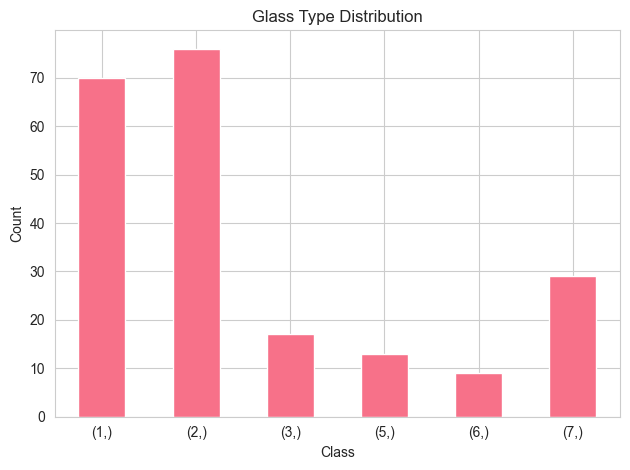

In [34]:
ax = y.value_counts().sort_index().plot(kind='bar')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Glass Type Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

___

### Feature distributions by class

In [35]:
df = X.copy()
df['species'] = y.values.ravel().astype(str)  # string żeby palette działała z seaborn
features = X.columns

# dynamiczna paleta dla klas w datasecie
classes = sorted(df['species'].unique())
colors = sns.color_palette('husl', len(classes))
palette = {cls: color for cls, color in zip(classes, colors)}

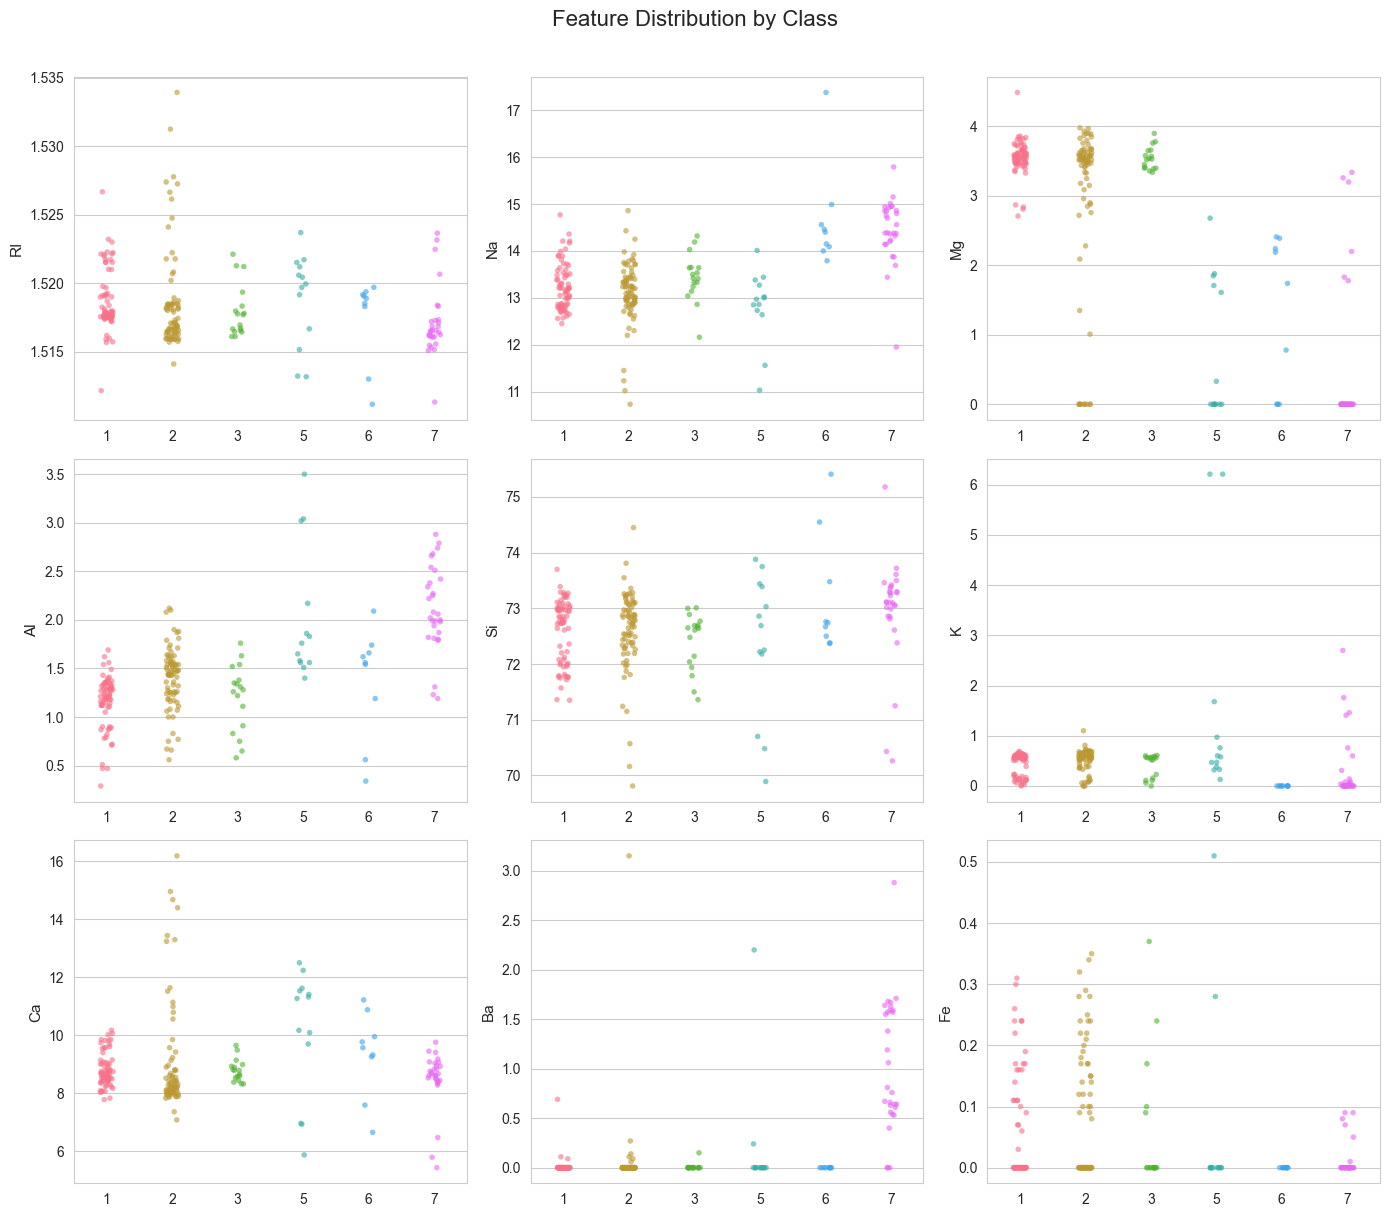

In [49]:
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
fig.suptitle('Feature Distribution by Class', fontsize=16, y=1.01)
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.stripplot(data=df, x='species', y=feature, hue='species',
                  ax=axes[idx], palette=palette, alpha=0.6, size=4, legend=False)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].tick_params(axis='x', rotation=0)

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

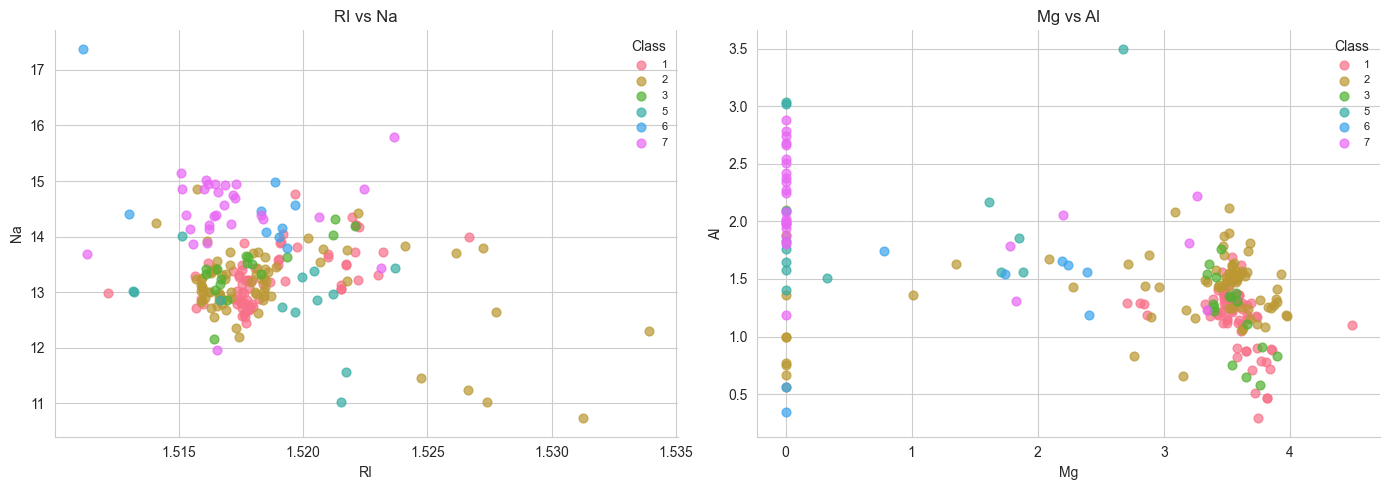

In [37]:
# Dwie wybrane pary cech
pairs = [(features[0], features[1]), (features[2], features[3])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fx, fy) in zip(axes, pairs):
    for cls, group in df.groupby('species'):
        ax.scatter(group[fx], group[fy], label=cls,
                   alpha=0.7, s=40, color=palette[cls])
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')
    ax.legend(title='Class', frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

___

### PCA

In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

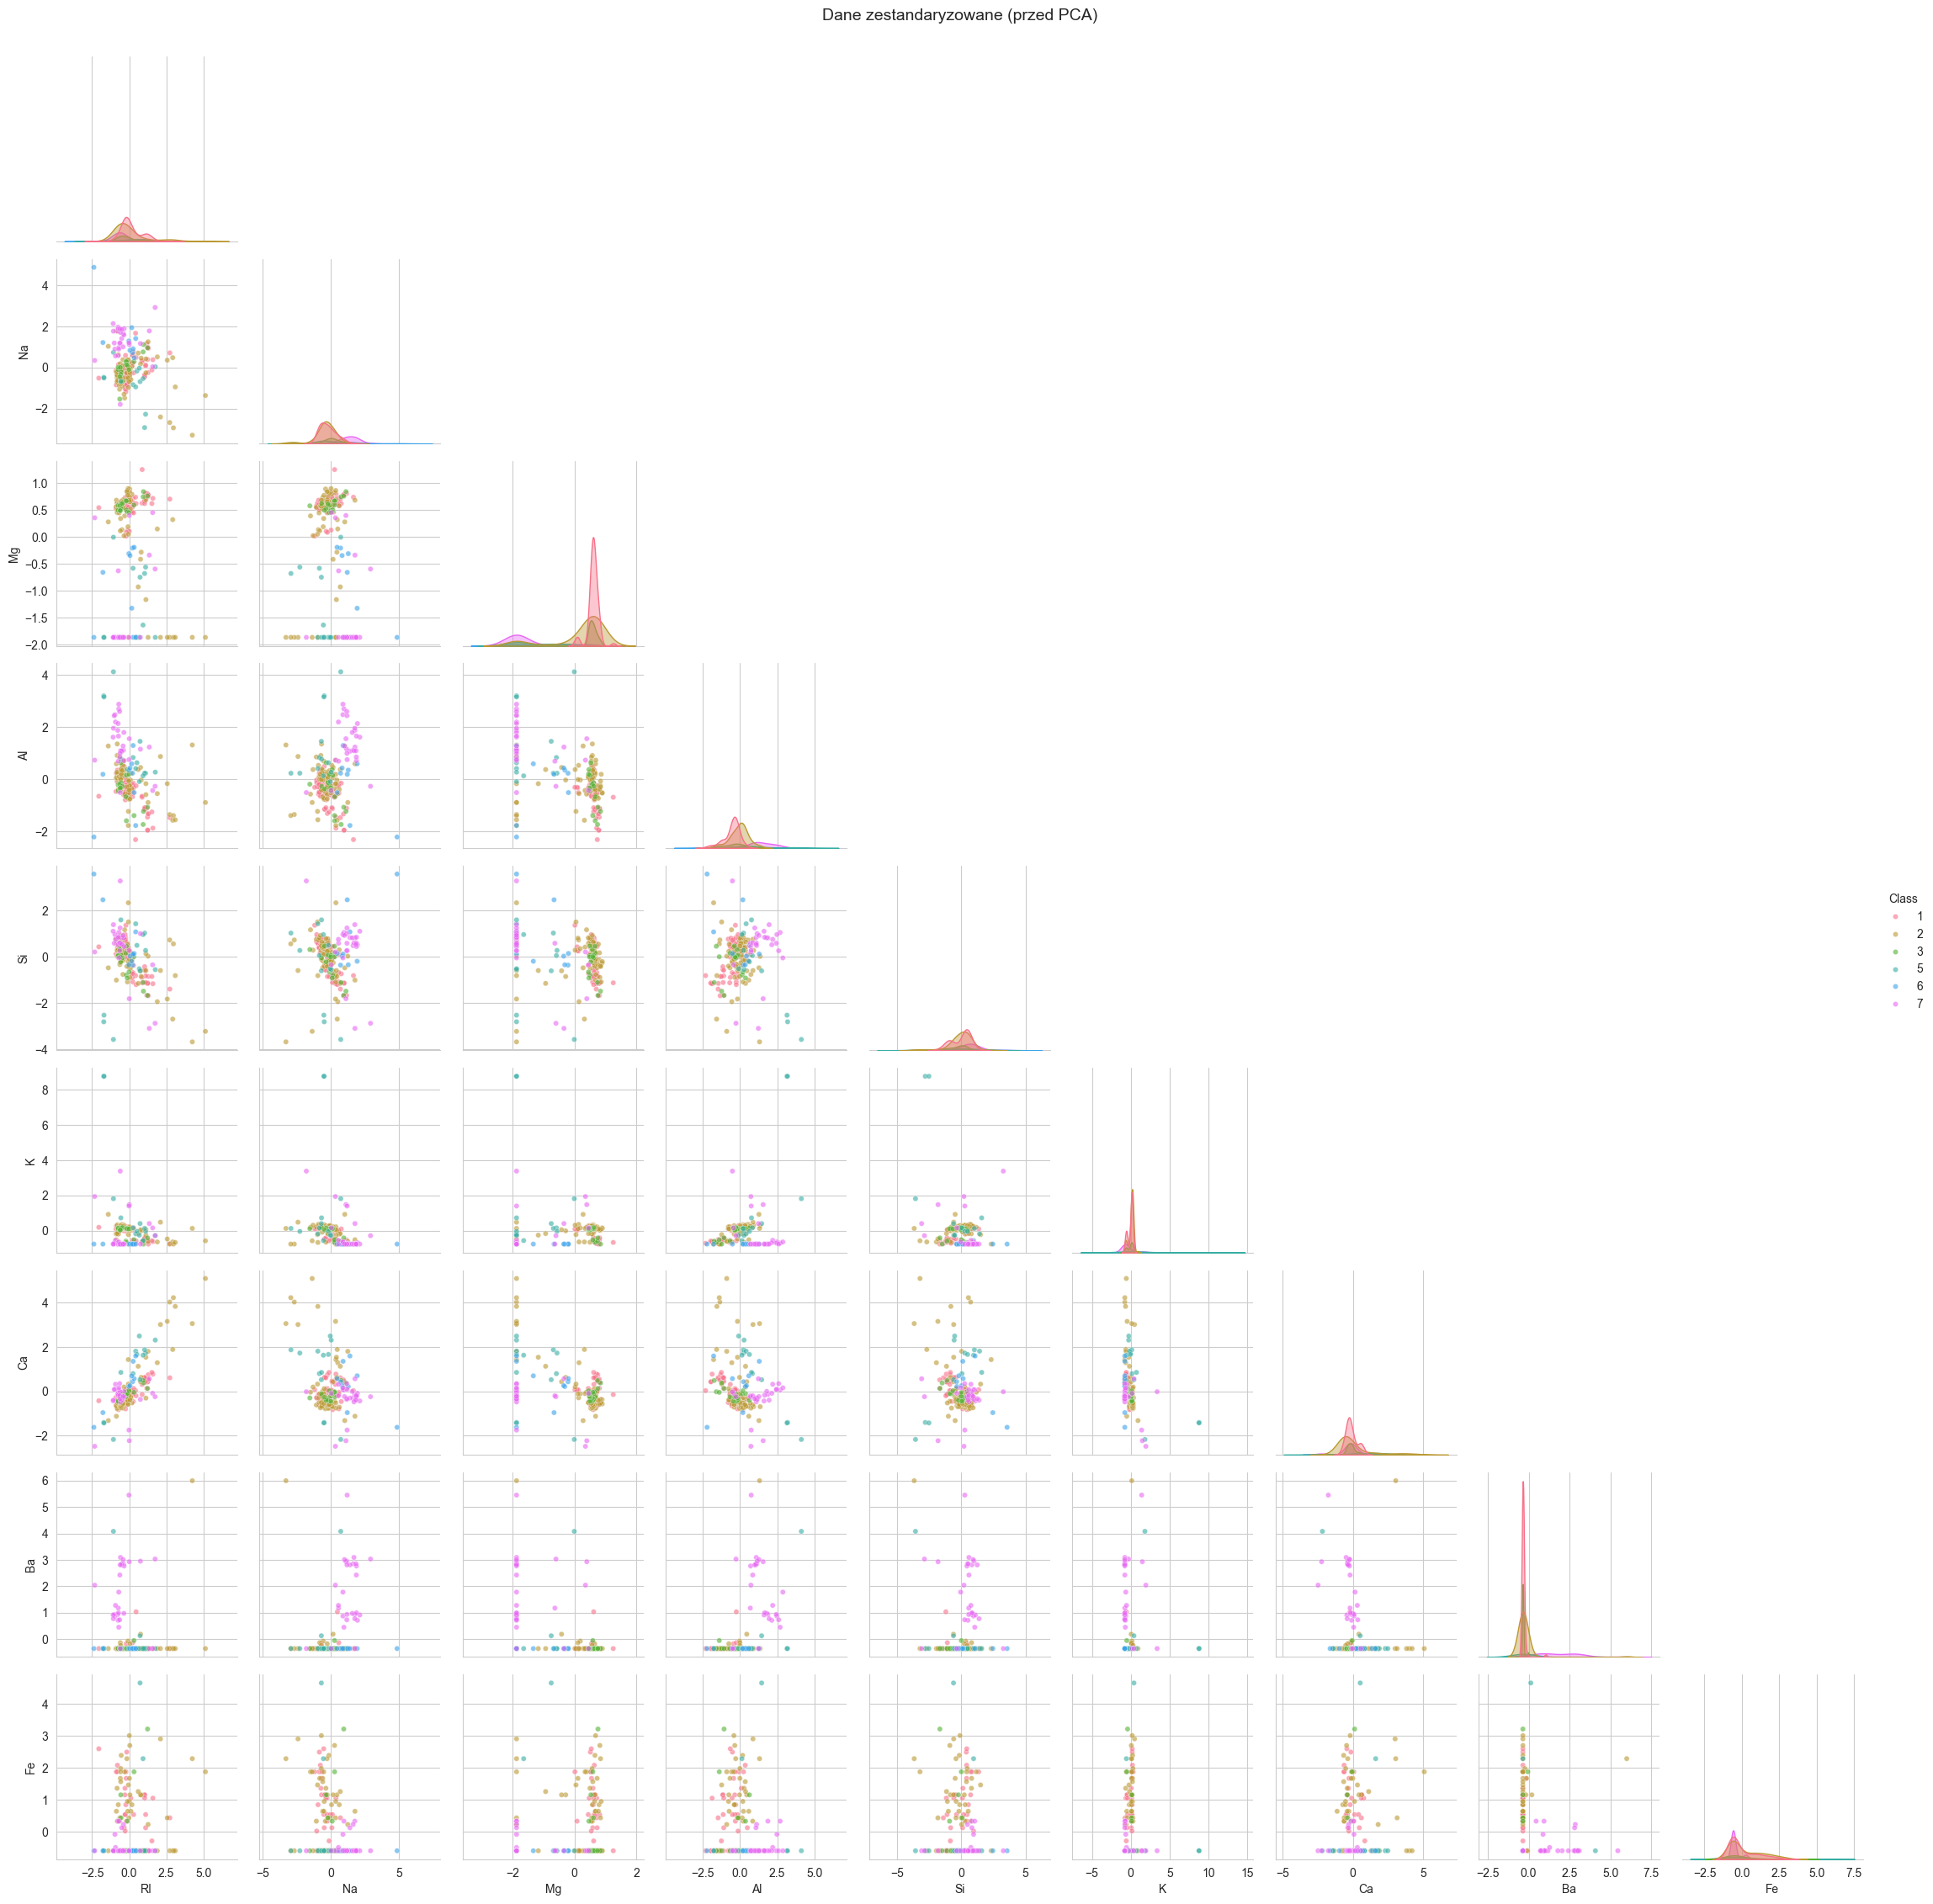

In [52]:
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['species'] = df['species'].values

g = sns.PairGrid(df_scaled, hue='species', palette=palette, corner=True)
g.map_lower(sns.scatterplot, alpha=0.6, s=20)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4, warn_singular=False)
g.add_legend(title='Class', frameon=False)

g.figure.suptitle('Dane zestandaryzowane (przed PCA)', y=1.01, fontsize=14)
plt.show()

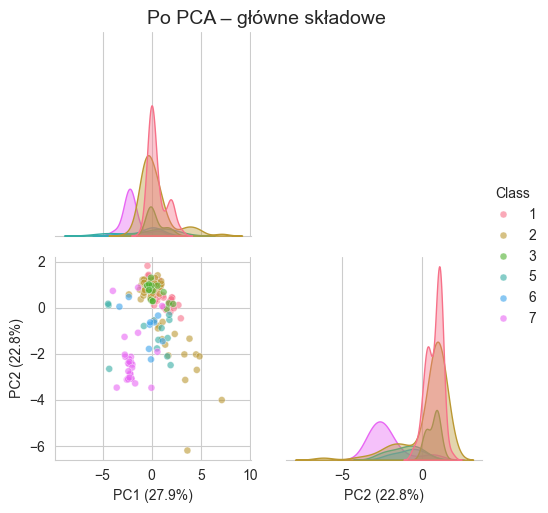

In [53]:
var = pca.explained_variance_ratio_ * 100
df_pca = pd.DataFrame(X_pca, columns=[f'PC1 ({var[0]:.1f}%)', f'PC2 ({var[1]:.1f}%)'])
df_pca['species'] = df['species'].values

g = sns.PairGrid(df_pca, hue='species', palette=palette, corner=True)
g.map_lower(sns.scatterplot, alpha=0.6, s=25)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4, warn_singular=False)
g.add_legend(title='Class', frameon=False)

g.figure.suptitle('Po PCA – główne składowe', y=1.01, fontsize=14)
plt.show()

### PCA – 3 wymiary

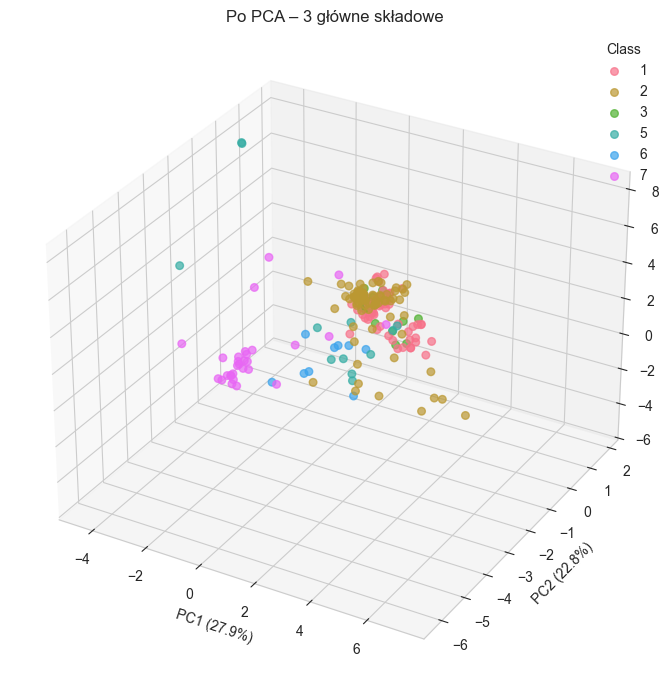

In [ ]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

var3 = pca3.explained_variance_ratio_ * 100
df_pca3 = pd.DataFrame(X_pca3, columns=[f'PC1 ({var3[0]:.1f}%)', f'PC2 ({var3[1]:.1f}%)', f'PC3 ({var3[2]:.1f}%)'])
df_pca3['species'] = df['species'].values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cls in classes:
    mask = df_pca3['species'] == cls
    ax.scatter(
        df_pca3.loc[mask, df_pca3.columns[0]],
        df_pca3.loc[mask, df_pca3.columns[1]],
        df_pca3.loc[mask, df_pca3.columns[2]],
        label=str(cls), color=palette[cls], alpha=0.7, s=30
    )

ax.set_xlabel(df_pca3.columns[0])
ax.set_ylabel(df_pca3.columns[1])
ax.set_zlabel(df_pca3.columns[2])
ax.legend(title='Class', frameon=False)
plt.tight_layout()
plt.show()
